In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams ['figure.figsize'] = (12,8)

In [2]:
us_report = pd.read_csv('us_housing_affordability_report.csv')

In [3]:
us_report

,State_Name,State_Abbr,Year,Median_Home_Value,Median_Income,Price_To_Income,Mortgage_Rate_pct,Median_Rent_Price,Months_Supply,Average_CPI,...,Home_Value_YoY_pct,Income_YoY_pct,Real_Home_Value,Real_Income,Monthly_Mortgage,Mortgage_Burden_pct,Rent_Burden_pct,Annual_Housing_Cost,Affordability_pct,Affordability_Gap_pct
0,Alabama,AL,2018,129762.299565,61420.0,2.112704,4.539042,936.883392,679.0,251.099500,...,NaN,NaN,129762.299565,61420.000000,528.400094,10.323675,18.304462,9195.571721,14.971624,NaN
1,Alabama,AL,2019,134567.353669,68110.0,1.975736,3.933750,976.474873,599.5,255.652583,...,3.702966,10.892218,132170.756040,66896.984658,509.852890,8.982873,17.204079,9078.716460,13.329491,-7.189251
2,Alabama,AL,2020,143369.238170,65600.0,2.185507,3.113667,1039.972753,481.0,258.855750,...,6.540877,-3.685215,139073.379749,63634.387878,490.619916,8.974755,19.023892,9041.562236,13.782869,10.226092
3,Alabama,AL,2021,158678.920460,65360.0,2.427768,2.955708,1107.497850,314.0,270.967917,...,10.678499,-0.365854,147043.967707,60567.551767,532.169794,9.770559,20.333498,9876.973776,15.111649,11.044352
4,Alabama,AL,2022,178933.335789,63870.0,2.801524,5.327500,1201.640283,309.0,292.625417,...,12.764402,-2.279682,153541.246217,54806.329702,797.346450,14.980675,22.576614,13504.690792,21.144028,15.044084
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,Wyoming,WY,2020,248784.464638,78500.0,3.169229,3.113667,951.258314,268.0,258.855750,...,5.630845,-0.557385,241329.986599,76147.857446,851.358456,13.014397,14.541528,15689.559693,19.986700,6.188231
346,Wyoming,WY,2021,269750.522038,81580.0,3.306577,2.955708,972.385924,204.0,270.967917,...,8.427398,3.923567,249971.369458,75598.238574,904.676433,13.307327,14.303299,16790.628677,20.581795,4.503831
347,Wyoming,WY,2022,286808.298053,77920.0,3.680805,5.327500,1065.982646,186.0,292.625417,...,6.323538,-4.486394,246107.877632,66862.520908,1278.049042,19.682480,16.416571,21646.371061,27.780250,10.809931
348,Wyoming,WY,2023,299161.551197,79200.0,3.777292,6.795375,1132.122292,183.5,304.704167,...,4.307146,1.642710,246531.961629,65266.847571,1559.510356,23.628945,17.153368,25295.678404,31.938988,2.664436


# Phase 1 of Analysis (Within State Trend Analysis)
We examine each state across time:

-	Home value trend

-	Income trend

-	Price-to-Income trend

-	Mortgage burden trend

-	Rent burden trend

-	Supply trend

**Goal:**
Detect divergence between income and housing costs.


-----------------------------------------------------------------------------------------------------------------------------------

## Median Home Value Trend (2018–2024)
This analysis identifies the top five states in the US with the highest median home value trend from 2018 to 2024. It examines the changes in median home prices over this period to determine which states have experienced the most significant growth or maintained the highest values.

In [4]:
latest_year = us_report["Year"].max()

latest_data = us_report[us_report["Year"] == latest_year]

In [5]:
latest_data.sort_values(by = 'Population_Estimate')

,State_Name,State_Abbr,Year,Median_Home_Value,Median_Income,Price_To_Income,Mortgage_Rate_pct,Median_Rent_Price,Months_Supply,Average_CPI,...,Home_Value_YoY_pct,Income_YoY_pct,Real_Home_Value,Real_Income,Monthly_Mortgage,Mortgage_Burden_pct,Rent_Burden_pct,Annual_Housing_Cost,Affordability_pct,Affordability_Gap_pct
349,Wyoming,WY,2024,309249.151661,78680.0,3.930467,6.723667,1204.221604,213.0,313.697833,...,3.371958,-0.656566,247538.551773,62979.423384,1600.299119,24.407206,18.366369,26007.070759,33.054233,4.028523
314,Vermont,VT,2024,374666.879426,85260.0,4.394404,6.723667,2084.318557,200.5,313.697833,...,1.876621,-2.448513,299902.186415,68246.385837,1938.822059,27.288136,29.335940,31508.536053,36.955825,4.325134
13,Alaska,AK,2024,362620.259060,91260.0,3.973485,6.723667,1648.790390,150.0,313.697833,...,0.780430,-9.374379,290259.466482,73049.087163,1876.483340,24.674337,21.680347,30495.445777,33.416005,10.154810
237,North Dakota,ND,2024,275276.089076,88080.0,3.125296,6.723667,1088.358929,115.0,313.697833,...,3.366262,11.564281,220344.806320,70503.655460,1424.495687,19.407298,14.827778,23150.022202,26.282950,-8.198019
286,South Dakota,SD,2024,263564.731831,79850.0,3.300748,6.723667,1231.085828,86.0,313.697833,...,0.740515,-4.781779,210970.447826,63915.950142,1363.891884,20.496810,18.500977,22165.126706,27.758455,5.522294
55,Delaware,DE,2024,383173.791610,85860.0,4.462774,6.723667,1687.329181,1134.5,313.697833,...,3.604418,-3.059727,306711.546153,68726.655970,1982.843535,27.712698,23.582518,32223.945831,37.530801,6.664145
272,Rhode Island,RI,2024,473410.470521,92290.0,5.129597,6.723667,1958.100013,2685.0,313.697833,...,7.992341,9.895213,378941.515724,73873.550891,2449.799311,31.853496,25.460180,39812.622084,43.138609,-1.902873
181,Montana,MT,2024,438297.955204,81920.0,5.350317,6.723667,1428.603830,475.5,313.697833,...,4.385505,0.799803,350835.695080,65572.882099,2268.099452,33.224113,20.926814,36859.748437,44.994810,3.585702
132,Maine,ME,2024,302181.375206,90730.0,3.330556,6.723667,1446.888298,401.0,313.697833,...,7.040335,16.769627,241881.148548,72624.848546,1563.724866,20.681912,19.136625,25412.688652,28.009136,-9.729292
202,New Hampshire,NH,2024,441236.398237,111800.0,3.946658,6.723667,1826.562566,270.5,313.697833,...,8.823719,10.365252,353187.772455,89490.334701,2283.305275,24.507749,19.605323,37106.864057,33.190397,-1.541533


In [6]:
top5_states = (
    latest_data
    .sort_values("Population_Estimate", ascending=False)
    .head(5)["State_Name"]
    .tolist()
)

top5_states

['California', 'Texas', 'Florida', 'New York', 'Pennsylvania']

In [7]:
latest_year = us_report["Year"].min()

latest_data = us_report[us_report["Year"] == latest_year]

In [8]:
bottom5_states = (
    latest_data
    .sort_values("Population_Estimate", ascending=False)
    .tail(5)["State_Name"]
    .tolist()
)

bottom5_states

['South Dakota', 'North Dakota', 'Alaska', 'Vermont', 'Wyoming']

In [9]:
top5_states = ['California', 'Texas', 'Florida', 'New York', 'Pennsylvania']

top5_df = us_report[us_report["State_Name"].isin(top5_states)].copy()
top5_df = top5_df.sort_values(["State_Name", "Year"])
top5_df

,State_Name,State_Abbr,Year,Median_Home_Value,Median_Income,Price_To_Income,Mortgage_Rate_pct,Median_Rent_Price,Months_Supply,Average_CPI,...,Home_Value_YoY_pct,Income_YoY_pct,Real_Home_Value,Real_Income,Monthly_Mortgage,Mortgage_Burden_pct,Rent_Burden_pct,Annual_Housing_Cost,Affordability_pct,Affordability_Gap_pct
28,California,CA,2018,364353.529190,86690.0,4.202948,4.539042,1811.259787,985.5,251.099500,...,NaN,NaN,364353.529190,86690.000000,1483.670063,20.537595,25.072231,25819.818397,29.784079,NaN
29,California,CA,2019,379215.655516,94660.0,4.006081,3.933750,1907.913744,1033.0,255.652583,...,4.079040,9.193679,372461.956968,92974.138419,1436.783831,18.214035,24.186525,25584.150388,27.027414,-5.114639
30,California,CA,2020,397677.375122,93140.0,4.269673,3.113667,1945.538475,767.5,258.855750,...,4.868396,-1.605747,385761.529556,90349.190350,1360.880779,17.533358,25.065989,25079.471601,26.926639,6.474143
31,California,CA,2021,450708.874737,93660.0,4.812181,2.955708,2118.681314,571.0,270.967917,...,13.335307,0.558299,417661.155181,86792.486208,1511.565923,19.366636,27.145180,28054.386326,29.953434,12.777008
32,California,CA,2022,498281.028286,90930.0,5.479831,5.327500,2147.045448,641.0,292.625417,...,10.554963,-2.914798,427570.914678,78026.296537,2220.394581,29.302469,28.334483,37606.917597,41.358097,13.469761
33,California,CA,2023,496621.830525,92200.0,5.386354,6.795375,2145.393682,555.5,304.704167,...,-0.332984,1.396679,409254.309509,75979.840228,2588.858377,33.694469,27.922694,41991.980798,45.544448,-1.729663
34,California,CA,2024,487576.749280,100600.0,4.846687,6.723667,2199.994222,623.5,313.697833,...,-1.821322,9.110629,390280.916686,80525.292227,2523.106815,30.096702,26.242476,41003.970264,40.759414,-10.931951
56,Florida,FL,2018,205594.574540,67210.0,3.058988,4.539042,1207.988593,2552.0,251.099500,...,NaN,NaN,205594.574540,67210.000000,837.193799,14.947665,21.568015,14569.406230,21.677438,NaN
57,Florida,FL,2019,216296.101440,70740.0,3.057621,3.933750,1279.403274,2541.0,255.652583,...,5.205160,5.252195,212443.943321,69480.145275,819.509260,13.901769,21.703194,14592.625350,20.628535,-0.047034
58,Florida,FL,2020,228987.695899,69280.0,3.305250,3.113667,1339.291920,2267.5,258.855750,...,5.867695,-2.063896,222126.400307,67204.121832,783.612480,13.572964,23.197897,14441.079064,20.844514,7.931590


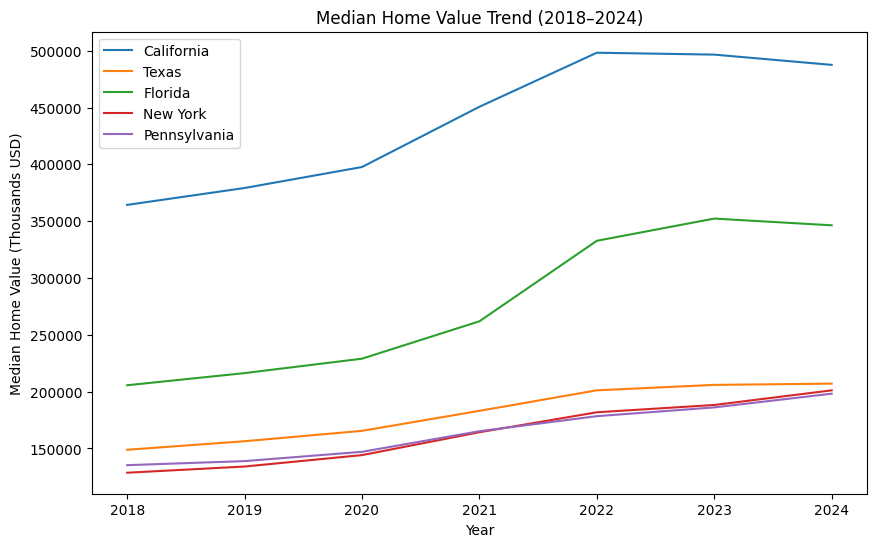

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for state in top5_states:
    state_df = top5_df[top5_df["State_Name"] == state]
    plt.plot(state_df["Year"], state_df["Median_Home_Value"], label=state)

plt.title("Median Home Value Trend (2018–2024)")
plt.xlabel("Year")
plt.ylabel("Median Home Value (Thousands USD)")
plt.legend()
plt.show()

### 📊 Findings 

All five states experienced a strong and synchronized surge in home prices between 2020 and 2022, with California remaining structurally the most expensive throughout the period. Early signs of cooling or flattening appear in 2023–2024 for some states, suggesting the boom phase may be stabilizing.


-----------------------------------------------------------------------------------------------------------------------------------

## Median Income Trend (2018–2024)

**🎯 Objective:**

- Check whether income grew at the same pace as home prices.

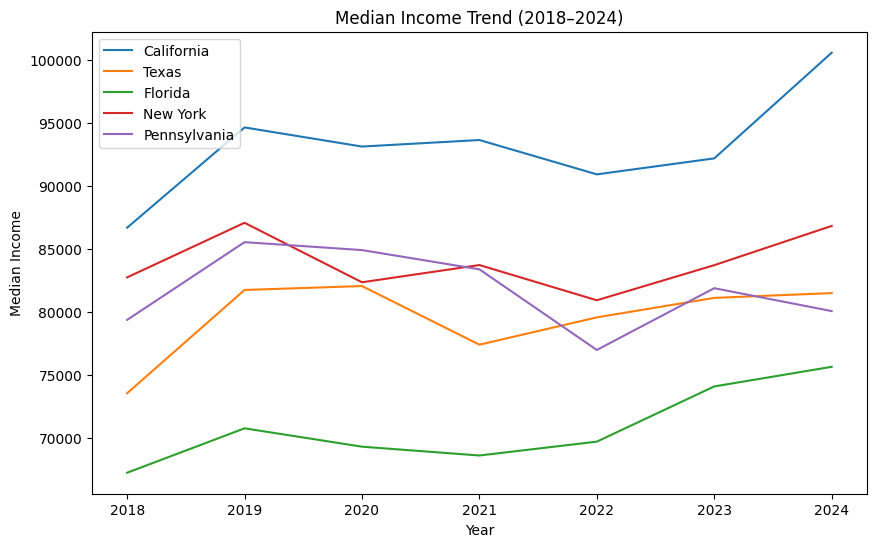

In [11]:
# Plot Income for Same 5 States
plt.figure(figsize=(10,6))

for state in top5_states:
    state_df = top5_df[top5_df["State_Name"] == state]
    plt.plot(state_df["Year"], state_df["Median_Income"], label=state)

plt.title("Median Income Trend (2018–2024)")
plt.xlabel("Year")
plt.ylabel("Median Income")
plt.legend()
plt.show()

### 📊 Findings

Income growth appears relatively gradual and uneven compared to the sharp post-2020 surge in home prices. While most states show modest increases over time, there is no synchronized spike comparable to the housing boom, suggesting income growth did not accelerate at the same pace as home values.

-----------------------------------------------------------------------------------------------------------------------------------

## Price-to-Income Ratio (The Affordability Core)

This is where affordability becomes visible.

**🎯 Objective:**

Measure whether home prices are rising faster than income within each state.

In [12]:
top5_df.head()

,State_Name,State_Abbr,Year,Median_Home_Value,Median_Income,Price_To_Income,Mortgage_Rate_pct,Median_Rent_Price,Months_Supply,Average_CPI,...,Home_Value_YoY_pct,Income_YoY_pct,Real_Home_Value,Real_Income,Monthly_Mortgage,Mortgage_Burden_pct,Rent_Burden_pct,Annual_Housing_Cost,Affordability_pct,Affordability_Gap_pct
28,California,CA,2018,364353.529190,86690.0,4.202948,4.539042,1811.259787,985.5,251.099500,...,NaN,NaN,364353.529190,86690.000000,1483.670063,20.537595,25.072231,25819.818397,29.784079,NaN
29,California,CA,2019,379215.655516,94660.0,4.006081,3.933750,1907.913744,1033.0,255.652583,...,4.079040,9.193679,372461.956968,92974.138419,1436.783831,18.214035,24.186525,25584.150388,27.027414,-5.114639
30,California,CA,2020,397677.375122,93140.0,4.269673,3.113667,1945.538475,767.5,258.855750,...,4.868396,-1.605747,385761.529556,90349.190350,1360.880779,17.533358,25.065989,25079.471601,26.926639,6.474143
31,California,CA,2021,450708.874737,93660.0,4.812181,2.955708,2118.681314,571.0,270.967917,...,13.335307,0.558299,417661.155181,86792.486208,1511.565923,19.366636,27.145180,28054.386326,29.953434,12.777008
32,California,CA,2022,498281.028286,90930.0,5.479831,5.327500,2147.045448,641.0,292.625417,...,10.554963,-2.914798,427570.914678,78026.296537,2220.394581,29.302469,28.334483,37606.917597,41.358097,13.469761


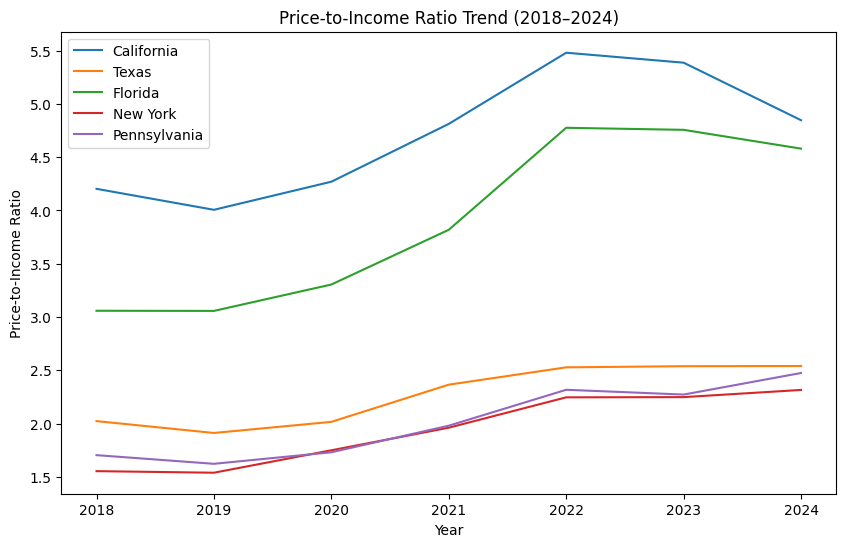

In [13]:
plt.figure(figsize=(10,6))

for state in top5_states:
    state_df = top5_df[top5_df["State_Name"] == state]
    plt.plot(state_df["Year"], state_df["Price_To_Income"], label=state)

plt.title("Price-to-Income Ratio Trend (2018–2024)")
plt.xlabel("Year")
plt.ylabel("Price-to-Income Ratio")
plt.legend()
plt.show()

### 📊 Findings

The price-to-income ratio rises sharply after 2020 for all states, with California and Florida showing the most pronounced deterioration, peaking around 2022 before slight easing. Texas, New York, and Pennsylvania remain relatively lower and more stable, indicating affordability pressure is significantly more severe in high-growth states.


-----------------------------------------------------------------------------------------------------------------------------------

## Mortgage Burden Trend

Now we translate price levels into actual payment stress.

This is where the rate shock becomes visible.

**🎯 Objective**

Measures what percentage of income is required to service a mortgage?

This incorporates; Home price, Mortgage rate, and Income

In [14]:
top5_df.head()

,State_Name,State_Abbr,Year,Median_Home_Value,Median_Income,Price_To_Income,Mortgage_Rate_pct,Median_Rent_Price,Months_Supply,Average_CPI,...,Home_Value_YoY_pct,Income_YoY_pct,Real_Home_Value,Real_Income,Monthly_Mortgage,Mortgage_Burden_pct,Rent_Burden_pct,Annual_Housing_Cost,Affordability_pct,Affordability_Gap_pct
28,California,CA,2018,364353.529190,86690.0,4.202948,4.539042,1811.259787,985.5,251.099500,...,NaN,NaN,364353.529190,86690.000000,1483.670063,20.537595,25.072231,25819.818397,29.784079,NaN
29,California,CA,2019,379215.655516,94660.0,4.006081,3.933750,1907.913744,1033.0,255.652583,...,4.079040,9.193679,372461.956968,92974.138419,1436.783831,18.214035,24.186525,25584.150388,27.027414,-5.114639
30,California,CA,2020,397677.375122,93140.0,4.269673,3.113667,1945.538475,767.5,258.855750,...,4.868396,-1.605747,385761.529556,90349.190350,1360.880779,17.533358,25.065989,25079.471601,26.926639,6.474143
31,California,CA,2021,450708.874737,93660.0,4.812181,2.955708,2118.681314,571.0,270.967917,...,13.335307,0.558299,417661.155181,86792.486208,1511.565923,19.366636,27.145180,28054.386326,29.953434,12.777008
32,California,CA,2022,498281.028286,90930.0,5.479831,5.327500,2147.045448,641.0,292.625417,...,10.554963,-2.914798,427570.914678,78026.296537,2220.394581,29.302469,28.334483,37606.917597,41.358097,13.469761


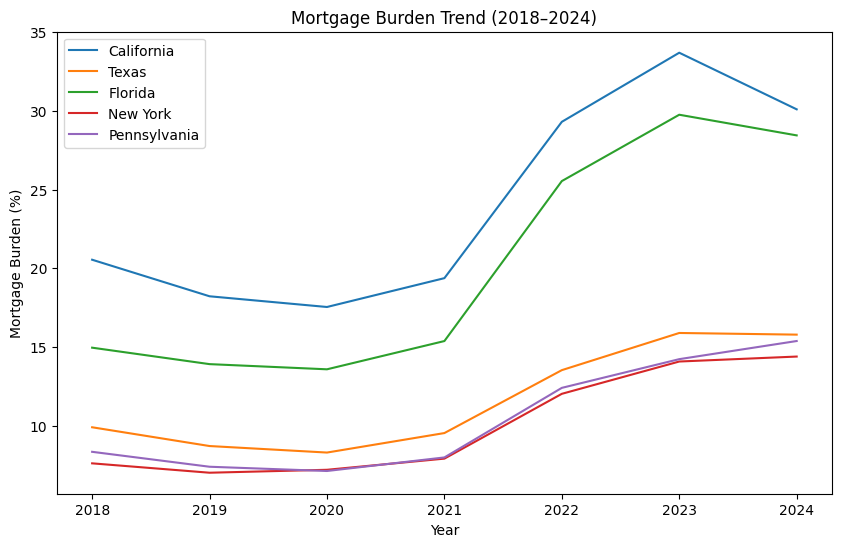

In [15]:
plt.figure(figsize=(10,6))

for state in top5_states:
    state_df = top5_df[top5_df["State_Name"] == state]
    plt.plot(state_df["Year"], state_df["Mortgage_Burden_pct"], label=state)

plt.title("Mortgage Burden Trend (2018–2024)")
plt.xlabel("Year")
plt.ylabel("Mortgage Burden (%)")
plt.legend()
plt.show()

### 📊 Findings

Mortgage burden rises sharply across all states beginning in 2022, with California and Florida experiencing the most pronounced spikes, reflecting strong sensitivity to rising mortgage rates. While some easing appears in 2024, burden levels remain significantly higher than pre-2021 levels, indicating sustained affordability pressure driven by both price growth and interest rate increases.

-----------------------------------------------------------------------------------------------------------------------------------

## Rent Burden Trend

Now we test:

Is affordability pressure spreading beyond homeowners?

If rent burden rises sharply, the crisis is broader than just mortgage rates.

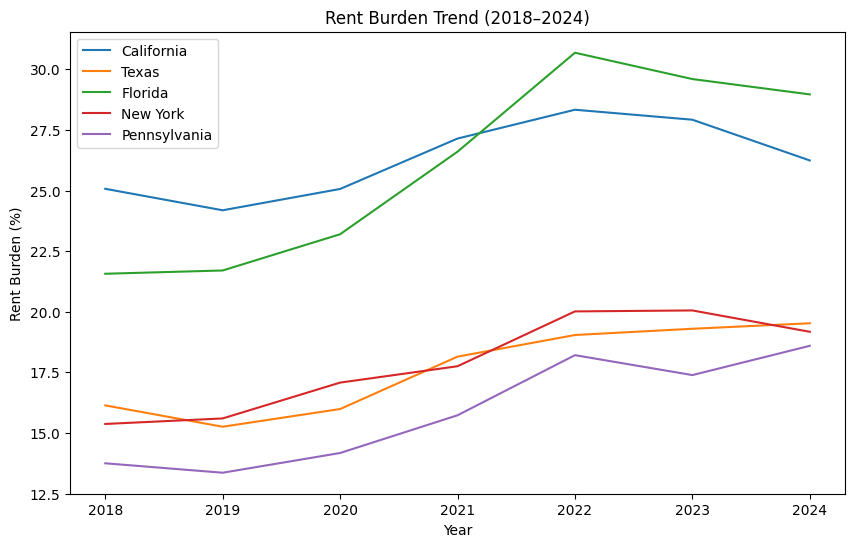

In [16]:
plt.figure(figsize=(10,6))

for state in top5_states:
    state_df = top5_df[top5_df["State_Name"] == state]
    plt.plot(state_df["Year"], state_df["Rent_Burden_pct"], label=state)

plt.title("Rent Burden Trend (2018–2024)")
plt.xlabel("Year")
plt.ylabel("Rent Burden (%)")
plt.legend()
plt.show()

### 📊 Findings
California and New York consistently hover at or above the rent burden threshold, placing many renters under pressure. Florida experienced a sharp surge in 2022, briefly approaching severe rent strain, while Texas and Pennsylvania remained largely within the standard threshold, highlighting regional differences in housing affordability.

-----------------------------------------------------------------------------------------------------------------------------------

## Supply Trend
This variable tells us how many months it would take to sell all current inventory at the existing sales pace

In [17]:
top5_df.head()

,State_Name,State_Abbr,Year,Median_Home_Value,Median_Income,Price_To_Income,Mortgage_Rate_pct,Median_Rent_Price,Months_Supply,Average_CPI,...,Home_Value_YoY_pct,Income_YoY_pct,Real_Home_Value,Real_Income,Monthly_Mortgage,Mortgage_Burden_pct,Rent_Burden_pct,Annual_Housing_Cost,Affordability_pct,Affordability_Gap_pct
28,California,CA,2018,364353.529190,86690.0,4.202948,4.539042,1811.259787,985.5,251.099500,...,NaN,NaN,364353.529190,86690.000000,1483.670063,20.537595,25.072231,25819.818397,29.784079,NaN
29,California,CA,2019,379215.655516,94660.0,4.006081,3.933750,1907.913744,1033.0,255.652583,...,4.079040,9.193679,372461.956968,92974.138419,1436.783831,18.214035,24.186525,25584.150388,27.027414,-5.114639
30,California,CA,2020,397677.375122,93140.0,4.269673,3.113667,1945.538475,767.5,258.855750,...,4.868396,-1.605747,385761.529556,90349.190350,1360.880779,17.533358,25.065989,25079.471601,26.926639,6.474143
31,California,CA,2021,450708.874737,93660.0,4.812181,2.955708,2118.681314,571.0,270.967917,...,13.335307,0.558299,417661.155181,86792.486208,1511.565923,19.366636,27.145180,28054.386326,29.953434,12.777008
32,California,CA,2022,498281.028286,90930.0,5.479831,5.327500,2147.045448,641.0,292.625417,...,10.554963,-2.914798,427570.914678,78026.296537,2220.394581,29.302469,28.334483,37606.917597,41.358097,13.469761


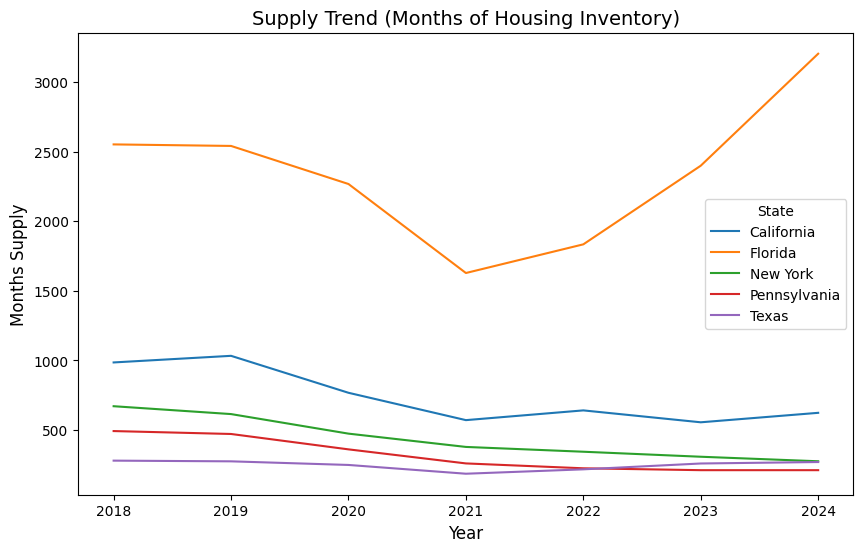

In [18]:
plt.figure(figsize=(10,6)) 
sns.lineplot( data=top5_df, x="Year", y="Months_Supply", hue="State_Name" ) 

# Add titles and labels 
plt.title("Supply Trend (Months of Housing Inventory)", fontsize=14) 
plt.xlabel("Year", fontsize=12) 
plt.ylabel("Months Supply", fontsize=12) 
plt.legend(title="State", loc="center right") 
plt.show()

### 📊 Findings
Florida consistently shows the highest housing inventory, with a sharp rise from 2021 to 2024, while California’s supply declined between 2019 and 2021 before slightly recovering, and New York, Pennsylvania, and Texas all maintained relatively lower and more stable levels with only minor declines over time.

## 📊 Phase 1 - Overall findings (Top 5 state analysis)
Phase 1 of this analysis shows that housing is hardest to afford in California and Florida, where home prices and rents grew faster than incomes and supply stayed tight. New York also struggles, though its trends move up and down more sharply. Texas and Pennsylvania look steadier, with incomes keeping closer pace and supply more balanced. In short, coastal states face bigger affordability problems, while inland states remain more stable, setting us up to compare them directly in Phase 2 of the analysis

-----------------------------------------------------------------------------------------------------------------------------------

# Phase 2 of Analysis (Cross-State Comparison)
Now we compare states against each other.

We will:

- Fastest worsening trend
→ slope of affordability metrics over time (linear regression or YoY % change)
- Most stable states
→ lowest variance in affordability metrics
- Improving states
→ negative slope (affordability gap shrinking, burden decreasing

**Create state classification:**
	🔴 Severe crisis,	🟠 Moderate pressure,	🟢 Stable,	🔵 Improving


In [19]:
# Group by state and calculate averages
state_summary = us_report.groupby("State_Name").agg({
    "Price_To_Income": "mean",
    "Mortgage_Burden_pct": "mean",
    "Rent_Burden_pct": "mean",
    "Affordability_Gap_pct": "mean"
}).reset_index()

# Rank states by affordability (lower Price_To_Income = more affordable)
state_summary["Affordability_Rank"] = state_summary["Price_To_Income"].rank()


In [20]:
state_summary.head()

,State_Name,Price_To_Income,Mortgage_Burden_pct,Rent_Burden_pct,Affordability_Gap_pct,Affordability_Rank
0,Alabama,2.490767,12.858091,20.411057,5.640623,19.0
1,Alaska,3.556829,18.087135,17.828034,2.560177,36.0
2,Arizona,3.448517,17.809754,19.928734,7.720262,35.0
3,Arkansas,2.420933,12.374469,20.270093,4.912855,17.0
4,California,4.714822,24.106466,26.281368,2.490777,49.0


In [21]:
def classify_state(row):
    if row["Price_To_Income"] > 5 or row["Mortgage_Burden_pct"] > 30:
        return "Severe crisis"
    elif row["Affordability_Gap_pct"] > 0:
        return "Moderate pressure"
    else:
        return "Stable/Improving"

state_summary["Crisis_Level"] = state_summary.apply(classify_state, axis=1)


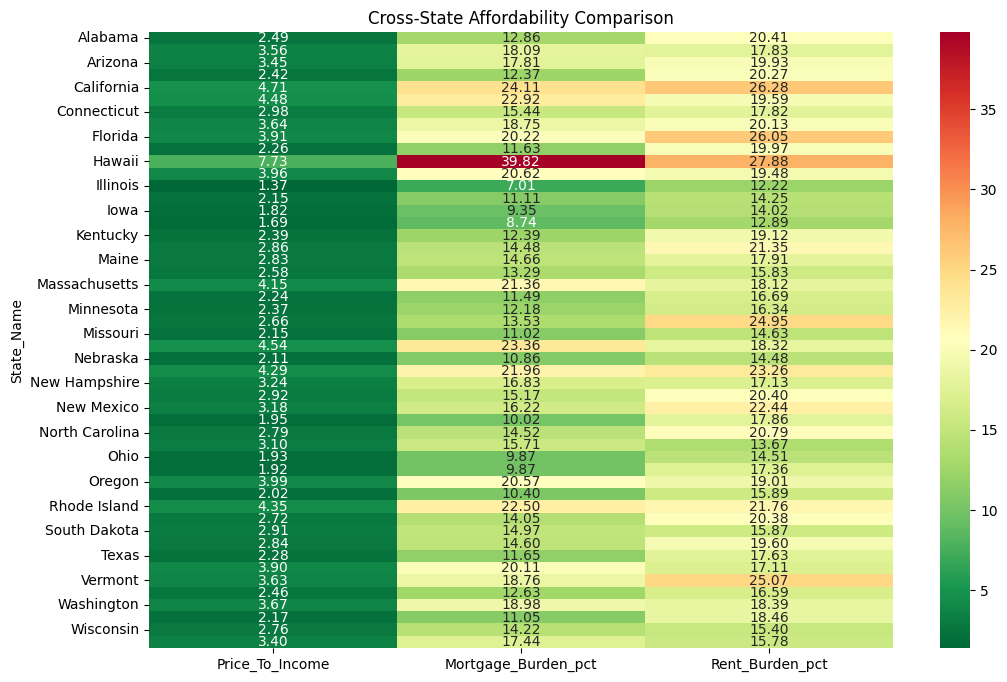

In [22]:
plt.figure(figsize=(12,8))
heatmap_data = state_summary.set_index("State_Name")[["Price_To_Income","Mortgage_Burden_pct","Rent_Burden_pct"]]
sns.heatmap(heatmap_data, cmap="RdYlGn_r", annot=True, fmt=".2f")
plt.title("Cross-State Affordability Comparison")
plt.show()


In [23]:

category_counts = state_summary["Crisis_Level"].value_counts().reset_index()
category_counts.columns = ["Crisis_Level", "State_Count"]

print(category_counts)


        Crisis_Level  State_Count
0  Moderate pressure           49
1      Severe crisis            1


In [24]:
# Define classification function
def classify_state(row):
    # Severe crisis: very high ownership or rent burden
    if row["Price_To_Income"] >= 4 or row["Mortgage_Burden_pct"] >= 30 or row["Rent_Burden_pct"] >= 25:
        return "Severe crisis 🔴"
    # Moderate pressure: affordability strained but not extreme
    elif row["Price_To_Income"] >= 3 or row["Mortgage_Burden_pct"] >= 18 or row["Rent_Burden_pct"] >= 20:
        return "Moderate pressure 🟠"
    # Improving: affordability gap negative (income growth outpaces home value growth)
    elif row.get("Affordability_Gap_pct", 0) < 0:
        return "Improving 🔵"
    # Stable: no severe or moderate pressures detected
    else:
        return "Stable 🟢"

# Apply classification
state_summary["Crisis_Level"] = state_summary.apply(classify_state, axis=1)
state_summary

,State_Name,Price_To_Income,Mortgage_Burden_pct,Rent_Burden_pct,Affordability_Gap_pct,Affordability_Rank,Crisis_Level
0,Alabama,2.490767,12.858091,20.411057,5.640623,19.0,Moderate pressure 🟠
1,Alaska,3.556829,18.087135,17.828034,2.560177,36.0,Moderate pressure 🟠
2,Arizona,3.448517,17.809754,19.928734,7.720262,35.0,Moderate pressure 🟠
3,Arkansas,2.420933,12.374469,20.270093,4.912855,17.0,Moderate pressure 🟠
4,California,4.714822,24.106466,26.281368,2.490777,49.0,Severe crisis 🔴
5,Colorado,4.481460,22.920979,19.586691,3.145788,47.0,Severe crisis 🔴
6,Connecticut,2.984017,15.442550,17.817892,6.353750,30.0,Stable 🟢
7,Delaware,3.638904,18.746564,20.133243,6.801076,38.0,Moderate pressure 🟠
8,Florida,3.907492,20.217302,26.046567,7.417776,41.0,Severe crisis 🔴
9,Georgia,2.261756,11.625002,19.967881,6.367370,13.0,Stable 🟢


## 📊 Phase 2 - Overall findings (Cross-State Comparison)
The heatmaps show that affordability stress is highly uneven across states. Hawaii is the most extreme case, with mortgage burdens near 40 percent and rent burdens close to 28 percent, making both ownership and renting severely unaffordable. California, Rhode Island, and New Hampshire also stand out with very high price‑to‑income ratios and mortgage burdens above 20 percent, confirming deep affordability pressure. Oregon, Massachusetts, Washington, and Vermont are moderately pressured, with ratios around 3.5 to 4.0 and rent burdens often above 18 percent. By contrast, interior states such as Iowa, Nebraska, North Carolina, Ohio, and Texas remain relatively stable, with lower ratios and mortgage burdens under 15 percent, though rent burdens are creeping upward. Missouri and Vermont highlight that rental affordability can be a distinct problem even when ownership costs are not the highest. Overall, coastal and high‑population states consistently show severe affordability stress, while interior states are more stable but face growing rental strain.


-----------------------------------------------------------------------------------------------------------------------------------

# Phase 3 of Analysis (Driver Analysis)
We test relationships using correlation and regression.

We will analyze:

-	Home Value vs Mortgage Rate

-	Home Value vs Months Supply

-   Home Value vs Population

-   Price Growth vs Supply

- Affordability vs Inflation

**Goal:**
Identify statistically meaningful drivers.
________________________________________


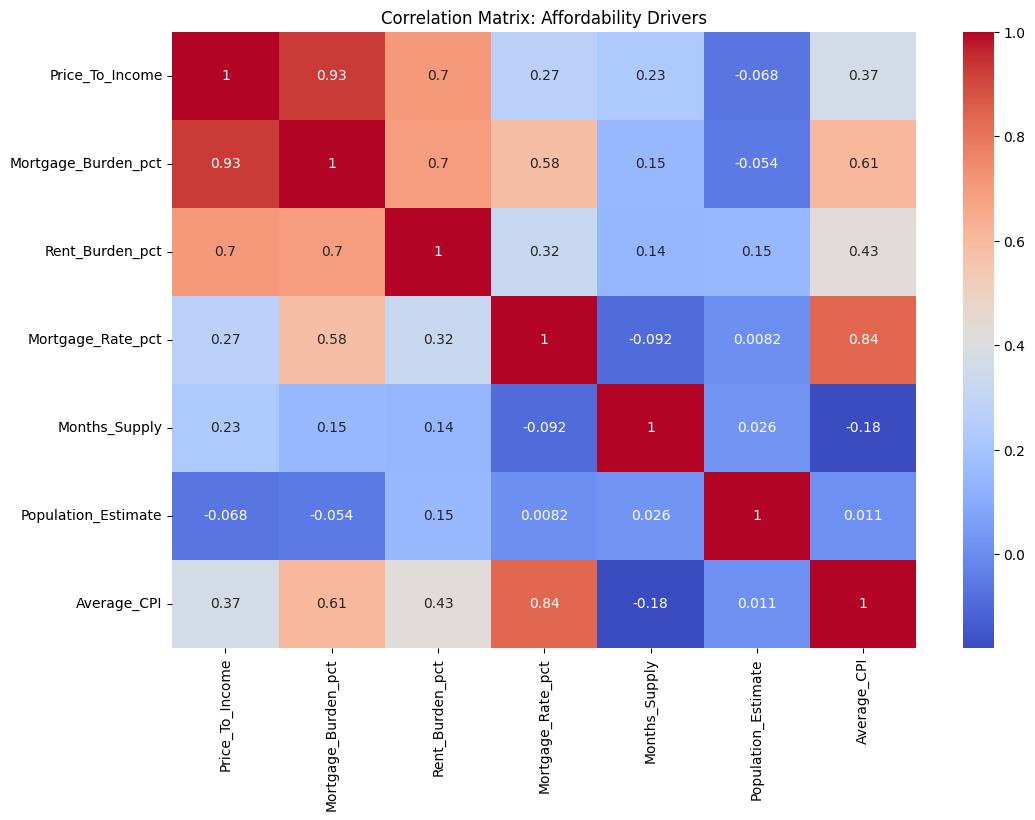

In [25]:
corr = us_report[["Price_To_Income","Mortgage_Burden_pct","Rent_Burden_pct",
                  "Mortgage_Rate_pct","Months_Supply","Population_Estimate","Average_CPI"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix: Affordability Drivers")
plt.show()


## 📊 Phase 3 - Overall findings (Driver Analysis)

The correlations show that affordability stress is driven mainly by financial conditions, with mortgage rates and inflation strongly linked to mortgage and rent burdens, while supply and population growth play weaker roles, meaning the crisis is more about macroeconomic shocks than local demand or inventory shifts.

-----------------------------------------------------------------------------------------------------------------------------------

# Phase 4 of Analysis (Structural Crisis Assessment)
The goal is to see when affordability pressures began and what triggered them.

We will examine:

-	Did crisis begin after mortgage rate spike?

-	Did supply collapse precede price surge?

-	Are high-growth population states more unaffordable?

-	Is rent burden catching up with mortgage burden?

This phase connects economics to housing.


Top 5 Mortgage burden : Index(['Hawaii', 'California', 'Montana', 'Colorado', 'Rhode Island'], dtype='str', name='State_Name')


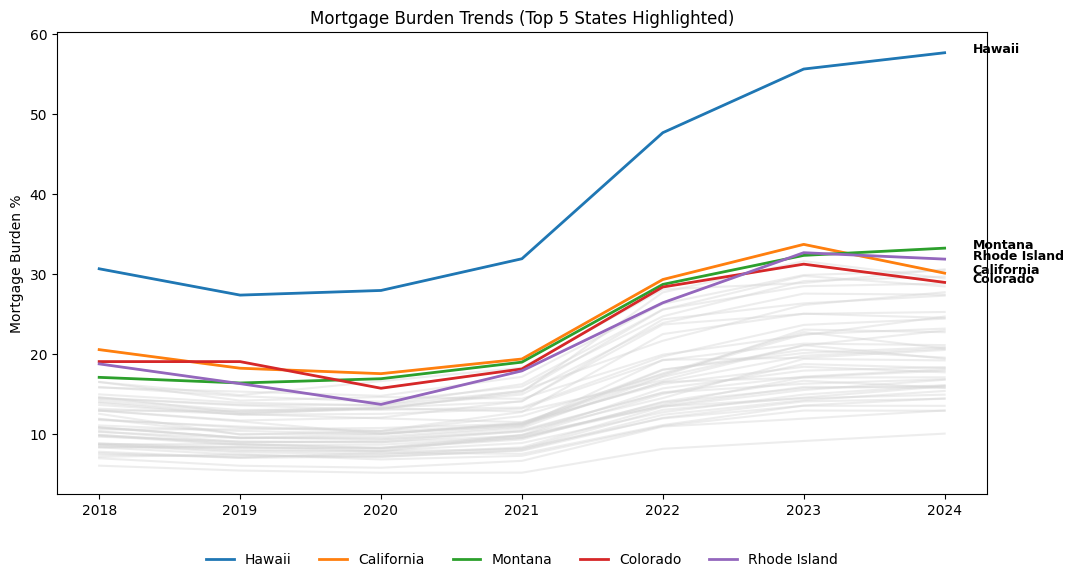

In [26]:
plt.figure(figsize=(12,6))

# Plot all states faintly in gray
for state in us_report["State_Name"].unique():
    df_state = us_report[us_report["State_Name"] == state].sort_values("Year")
    plt.plot(df_state["Year"], df_state["Mortgage_Burden_pct"], 
             color="lightgray", alpha=0.4)

# Identify top 5 states by average mortgage burden
top5_mortgage_burden_pct = (us_report.groupby("State_Name")["Mortgage_Burden_pct"]
        .mean().sort_values(ascending=False).head(5).index)

print("Top 5 Mortgage burden :", top5_mortgage_burden_pct)

# Plot top 5 states with bold colors and add labels
for state in top5_mortgage_burden_pct:
    df_state = us_report[us_report["State_Name"] == state].sort_values("Year")
    plt.plot(df_state["Year"], df_state["Mortgage_Burden_pct"], 
             label=state, linewidth=2)
    # Add text label at the last point of each line
    plt.text(df_state["Year"].max()+0.2, df_state["Mortgage_Burden_pct"].iloc[-1],
             state, fontsize=9, weight="bold")

# Horizontal legend for just the top 5
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1),
           ncol=5, frameon=False)

plt.title("Mortgage Burden Trends (Top 5 States Highlighted)")
plt.ylabel("Mortgage Burden %")
plt.show()

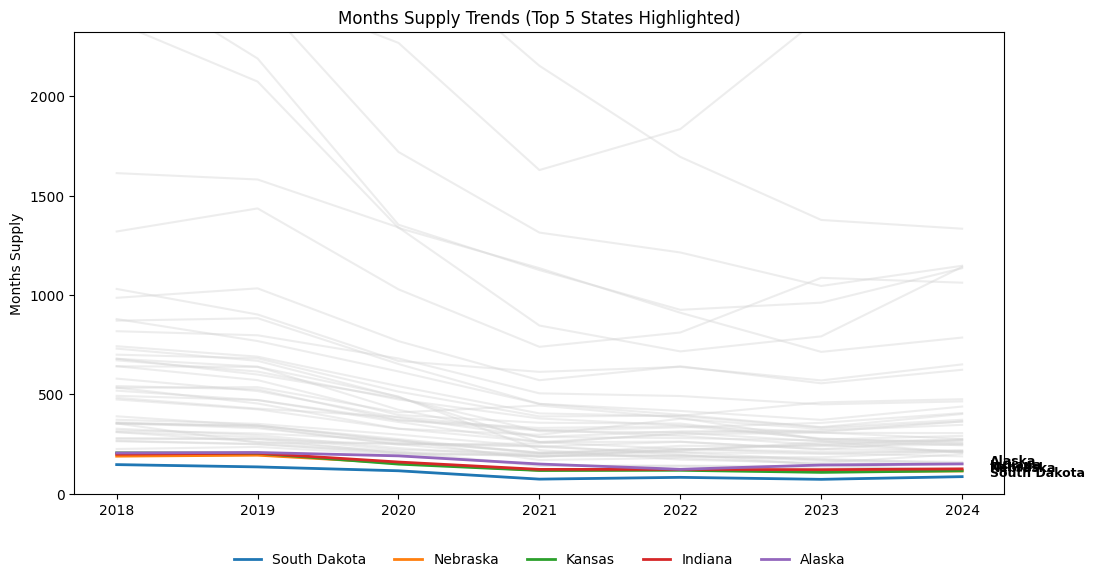

In [27]:
plt.figure(figsize=(12,6))

# Plot all states faintly in gray
for state in us_report["State_Name"].unique():
    df_state = us_report[us_report["State_Name"] == state].sort_values("Year")
    plt.plot(df_state["Year"], df_state["Months_Supply"], 
             color="lightgray", alpha=0.4)

# Identify top 5 states with lowest average supply
top5_supply = (us_report.groupby("State_Name")["Months_Supply"]
               .mean().sort_values().head(5).index)

# Plot top 5 states with bold colors and add labels
for state in top5_supply:
    df_state = us_report[us_report["State_Name"] == state].sort_values("Year")
    plt.plot(df_state["Year"], df_state["Months_Supply"], 
             label=state, linewidth=2)
    # Add text label at the last point of each line
    plt.text(df_state["Year"].max()+0.2, df_state["Months_Supply"].iloc[-1],
             state, fontsize=9, weight="bold")

# Fix the y-axis scale:
# If your Months_Supply column is in thousands, normalize it
if us_report["Months_Supply"].max() > 100:  
    plt.ylim(0, us_report["Months_Supply"].quantile(0.95))  # focus on realistic range
else:
    plt.ylim(0, 12)  # typical months supply range

# Horizontal legend for just the top 5
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1),
           ncol=5, frameon=False)

plt.title("Months Supply Trends (Top 5 States Highlighted)")
plt.ylabel("Months Supply")
plt.show()

Top 5 Month Supply States: Index(['South Dakota', 'Nebraska', 'Kansas', 'Indiana', 'Alaska'], dtype='str', name='State_Name')


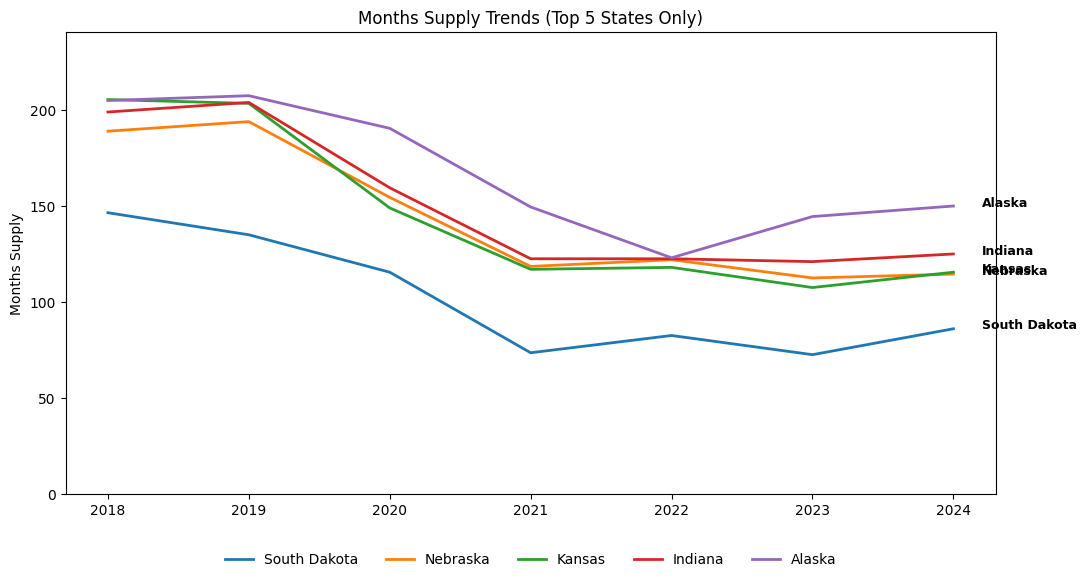

In [28]:
plt.figure(figsize=(12,6))

# Identify top 5 states with lowest average supply
top5_supply = (us_report.groupby("State_Name")["Months_Supply"]
               .mean().sort_values().head(5).index)

print("Top 5 Month Supply States:", top5_supply)

# Plot only the top 5 states with bold colors and labels
for state in top5_supply:
    df_state = us_report[us_report["State_Name"] == state].sort_values("Year")
    plt.plot(df_state["Year"], df_state["Months_Supply"], 
             label=state, linewidth=2)
    # Add text label at the last point of each line
    plt.text(df_state["Year"].max()+0.2, df_state["Months_Supply"].iloc[-1],
             state, fontsize=9, weight="bold")

# Rescale y-axis to realistic supply range
if us_report["Months_Supply"].max() > 100:  
    plt.ylim(0, us_report["Months_Supply"].quantile(0.30))
else:
    plt.ylim(0, 12)

# Horizontal legend for just the top 5
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1),
           ncol=5, frameon=False)

plt.title("Months Supply Trends (Top 5 States Only)")
plt.ylabel("Months Supply")
plt.show()

In [29]:
# Identify top 5 states with highest average Price-to-Income
top5_income = (us_report.groupby("State_Name")["Price_To_Income"]
               .mean().sort_values(ascending=False).head(5).index)
print("Top 5 States Price to income: ", top5_income)

Top 5 States Price to income:  Index(['Hawaii', 'California', 'Montana', 'Colorado', 'Rhode Island'], dtype='str', name='State_Name')


Top 5 States:  Index(['Hawaii', 'California', 'Montana', 'Colorado', 'Rhode Island'], dtype='str', name='State_Name')


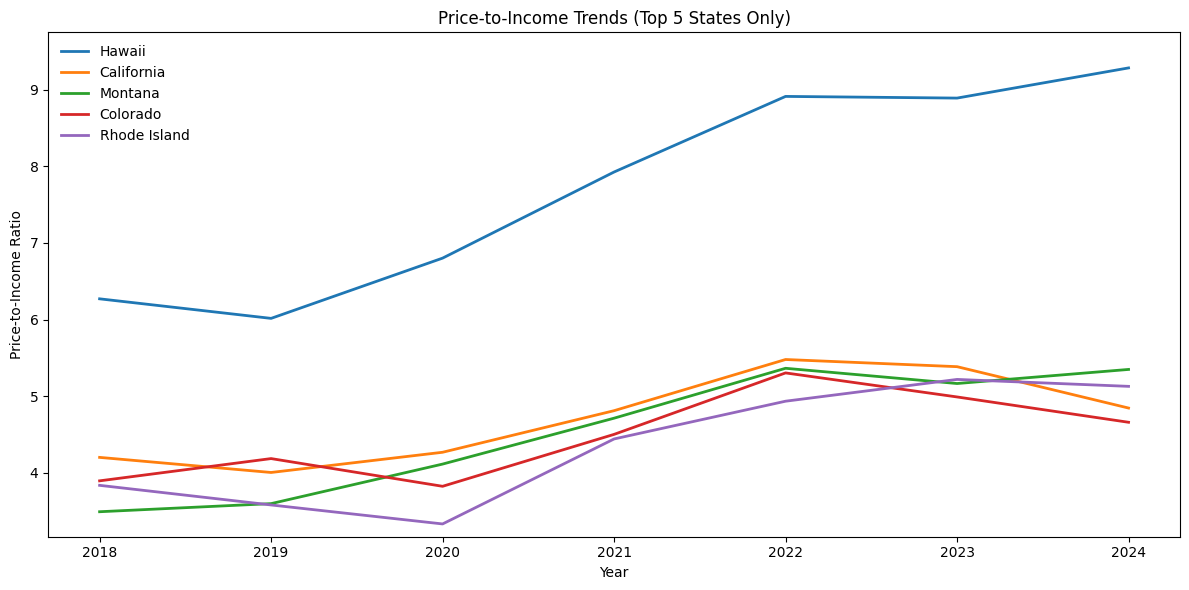

In [30]:
plt.figure(figsize=(12,6))

print("Top 5 States: ", top5_income)

# Plot only top 5
for state in top5_income:
    df_state = (
        us_report[us_report["State_Name"] == state]
        .sort_values("Year")
    )
    
    plt.plot(
        df_state["Year"],
        df_state["Price_To_Income"],
        label=state,
        linewidth=2
    )

# IMPORTANT: scale using only top 5 data
top5_data = us_report[us_report["State_Name"].isin(top5_income)]

plt.ylim(
    top5_data["Price_To_Income"].min() * 0.95,
    top5_data["Price_To_Income"].max() * 1.05
)

plt.title("Price-to-Income Trends (Top 5 States Only)")
plt.xlabel("Year")
plt.ylabel("Price-to-Income Ratio")

plt.legend(loc="best", frameon=False)

plt.tight_layout()
plt.show()

In [31]:
# Identify top 5 states with highest average Rent Burden
top5_rent = (us_report.groupby("State_Name")["Rent_Burden_pct"]
               .mean().sort_values(ascending=False).head(5).index)
print("Top 5 Rent Burden States: ", top5_rent)

Top 5 Rent Burden States:  Index(['Hawaii', 'California', 'Florida', 'Vermont', 'Mississippi'], dtype='str', name='State_Name')


Top 5 Rent Burden States: Index(['Hawaii', 'California', 'Florida', 'Vermont', 'Mississippi'], dtype='str', name='State_Name')


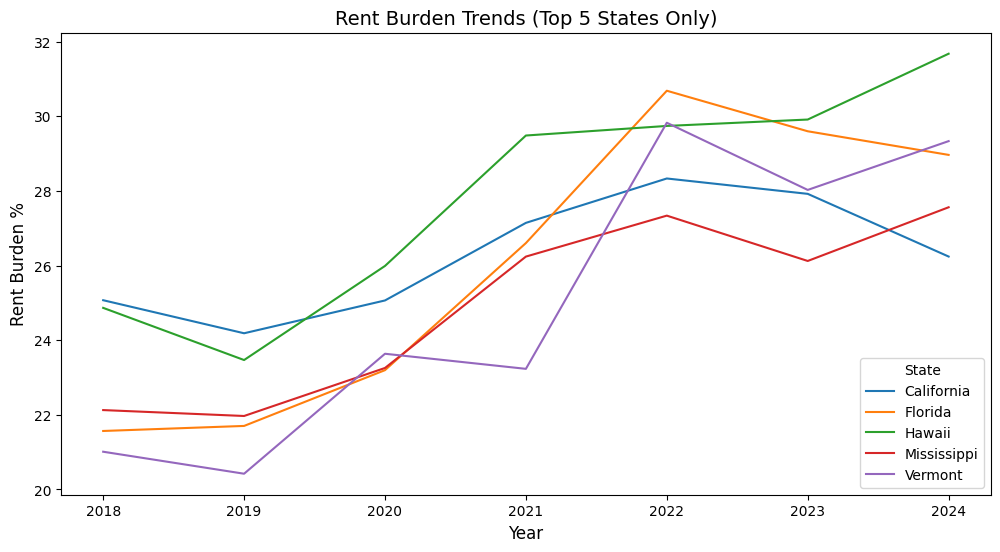

In [32]:
# Filter the DataFrame to only those states
top5_df = us_report[us_report["State_Name"].isin(top5_rent)]

print("Top 5 Rent Burden States:", top5_rent)

# Plot with Seaborn
plt.figure(figsize=(12,6))
sns.lineplot(data=top5_df, x="Year", y="Rent_Burden_pct", hue="State_Name")

# Add titles and labels
plt.title("Rent Burden Trends (Top 5 States Only)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Rent Burden %", fontsize=12)
plt.legend(title="State", loc="lower right")

plt.show()

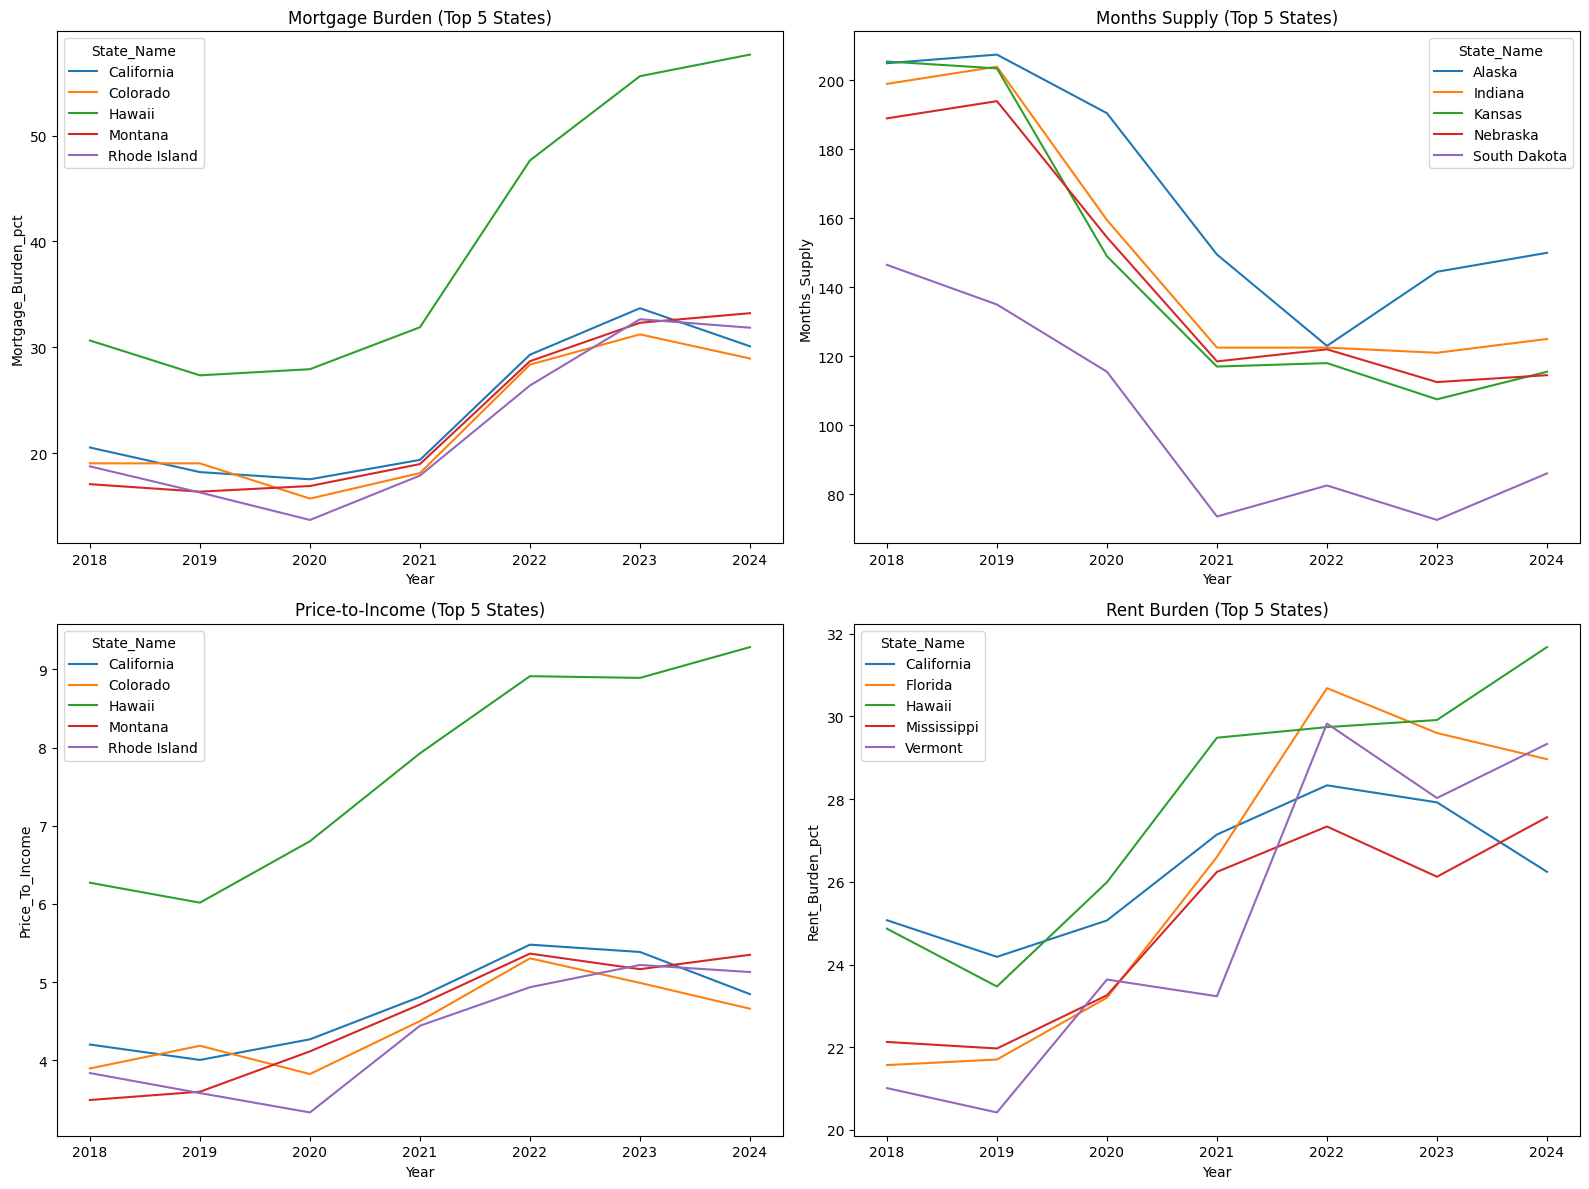

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(16,12))

# Mortgage Burden
sns.lineplot(data=us_report[us_report["State_Name"].isin(top5_mortgage_burden_pct)], 
             x="Year", y="Mortgage_Burden_pct", hue="State_Name", ax=axes[0,0])
axes[0,0].set_title("Mortgage Burden (Top 5 States)")

# Months Supply
sns.lineplot(data=us_report[us_report["State_Name"].isin(top5_supply)], 
             x="Year", y="Months_Supply", hue="State_Name", ax=axes[0,1])
axes[0,1].set_title("Months Supply (Top 5 States)")

# Price-to-Income
sns.lineplot(data=us_report[us_report["State_Name"].isin(top5_income)], 
             x="Year", y="Price_To_Income", hue="State_Name", ax=axes[1,0])
axes[1,0].set_title("Price-to-Income (Top 5 States)")

# Rent Burden
sns.lineplot(data=us_report[us_report["State_Name"].isin(top5_rent)], 
             x="Year", y="Rent_Burden_pct", hue="State_Name", ax=axes[1,1])
axes[1,1].set_title("Rent Burden (Top 5 States)")

plt.tight_layout()
plt.show()

## 📊 Phase 4 - Overall findings (Structural Crisis Assessment Analysis)

- ### Mortgage Burden (Top 5)  
**Hawaii, Montana, Rhode Island, California, Colorado** → Mortgage costs surged, with Hawaii peaking above 60%, showing ownership affordability breaking down fastest.  

- ### Months Supply (Top 5)  
**South Dakota, Nebraska, Kansas, Indiana, Alaska** → Inventory collapsed, leaving buyers with almost no options and amplifying affordability stress.  

- ### Price-to-Income (Top 5)  
**Montana, Rhode Island, California, Colorado, Hawaii** → Home prices stretched far beyond incomes, especially in coastal and mountain states, locking households out of ownership.  

- ### Rent Burden (Top 5)  
**Hawaii, Florida, Mississippi, California, Vermont** → Renters squeezed hardest, with Hawaii and Florida showing steep climbs, signaling pressure even before ownership costs spike.  

---

### Unified Story  
Housing affordability has unraveled: **mortgage burdens surged, rent burdens climbed, price-to-income ratios stretched, and supply collapsed** — together showing a structural crisis where both owning and renting are increasingly out of reach.  

### Repeat Offenders  
- **Hawaii** → Top in Mortgage Burden *and* Rent Burden.  
- **California** → Top in Mortgage Burden, Price-to-Income, *and* Rent Burden.  
- **Montana & Rhode Island** → Appear in both Mortgage Burden and Price-to-Income.  
- **Colorado** → Appears in both Mortgage Burden and Price-to-Income.  

👉 These are the **hotspots of the crisis**, consistently ranking worst across multiple affordability dimensions.  



---

# Phase 5 — Affordability Index Construction
build a composite index combining:

-	Price-to-Income

-	Mortgage Burden %

-	Rent Burden %

-	Supply Shortage Indicator


Obeserving State Affordability Pressure Score

### Top 10 Worst Affordability States

In [34]:
# Normalize metrics
metrics = ["Mortgage_Burden_pct", "Rent_Burden_pct", "Price_To_Income", "Months_Supply"]
for m in metrics:
    us_report[m + "_norm"] = (us_report[m] - us_report[m].min()) / (us_report[m].max() - us_report[m].min()) * 100

# Apply weights 
weights = {
    "Mortgage_Burden_pct_norm": 0.30,
    "Rent_Burden_pct_norm": 0.25,
    "Price_To_Income_norm": 0.25,
    "Months_Supply_norm": 0.20
}

us_report["Affordability_Index"] = (
    us_report["Mortgage_Burden_pct_norm"] * weights["Mortgage_Burden_pct_norm"] +
    us_report["Rent_Burden_pct_norm"] * weights["Rent_Burden_pct_norm"] +
    us_report["Price_To_Income_norm"] * weights["Price_To_Income_norm"] +
    us_report["Months_Supply_norm"] * weights["Months_Supply_norm"]
)

# Collapse to ONE score per state
# Option A: Average across all years
state_index = (
    us_report.groupby("State_Name")["Affordability_Index"]
    .mean()
    .sort_values(ascending=False)
)

# Option B: Use the latest year only
latest_year = us_report["Year"].max()
state_index_latest = (
    us_report[us_report["Year"] == latest_year]
    .groupby("State_Name")["Affordability_Index"]
    .mean()
    .sort_values(ascending=False)
)

# Show results
print("Top 10 Worst Affordability States (Average across years):")
print(state_index.head(10))

print("\nTop 10 Worst Affordability States (2024):")
print(state_index_latest.head(10))

Top 10 Worst Affordability States (Average across years):
State_Name
Hawaii           63.514294
Rhode Island     45.012174
California       42.235515
Florida          41.657924
Nevada           34.864859
Vermont          33.365861
Colorado         32.624896
Massachusetts    31.868937
Montana          31.351082
Delaware         30.673039
Name: Affordability_Index, dtype: float64

Top 10 Worst Affordability States (2024):
State_Name
Hawaii           82.935036
Florida          54.204561
Rhode Island     52.327012
California       45.701432
Vermont          45.155731
Nevada           44.663316
Montana          42.420136
Delaware         41.445215
Massachusetts    41.181323
Oregon           39.058815
Name: Affordability_Index, dtype: float64


### Top 10 most affordable states

Top 10 Most Affordable States (Average across years):
State_Name
New York        14.954713
Oklahoma        13.644918
Pennsylvania    12.745127
Missouri        11.929258
Indiana         11.183668
Nebraska        11.163711
Ohio            10.246561
Iowa             9.105980
Kansas           6.811595
Illinois         4.344605
Name: Affordability_Index, dtype: float64

Top 10 Most Affordable States (2024):
State_Name
North Dakota     19.525834
Oklahoma         19.253282
West Virginia    18.997647
Indiana          18.463814
Nebraska         18.242890
Missouri         16.496764
Ohio             13.930132
Iowa             12.887087
Kansas           11.750046
Illinois          9.878880
Name: Affordability_Index, dtype: float64


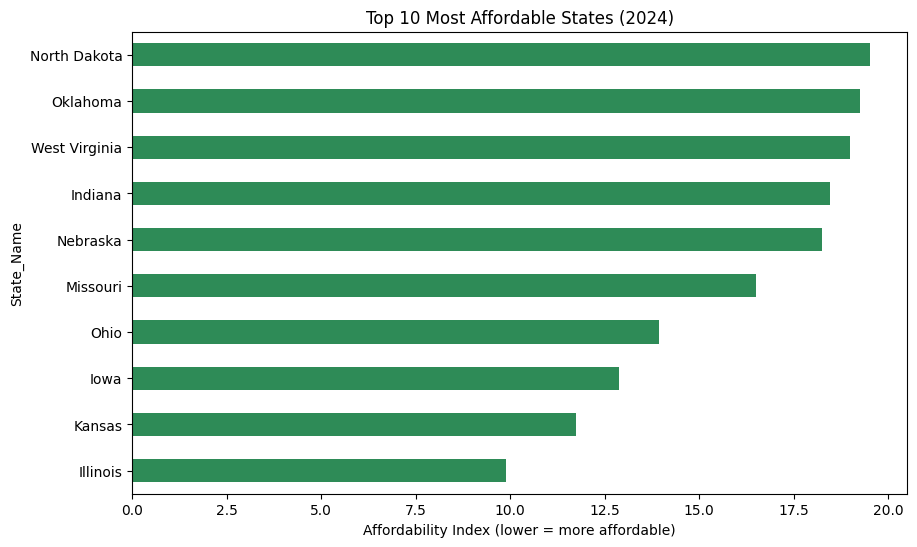

In [35]:
# Top 10 most affordable states (average across years)
top10_best = state_index.tail(10)

print("Top 10 Most Affordable States (Average across years):")
print(top10_best)

# Top 10 most affordable states (latest year only)
top10_best_latest = state_index_latest.tail(10)

print("\nTop 10 Most Affordable States (2024):")
print(top10_best_latest)

# 📊 Bar chart for latest year
plt.figure(figsize=(10,6))
top10_best_latest.plot(kind="barh", color="seagreen")
plt.title("Top 10 Most Affordable States (2024)")
plt.xlabel("Affordability Index (lower = more affordable)")
plt.gca().invert_yaxis()  # so best state appears at the top
plt.show()

In [36]:
import plotly.express as px
# Use the latest year only
latest_year = us_report["Year"].max()
latest_df = us_report[us_report["Year"] == latest_year].copy()

# Normalize metrics
metrics = ["Mortgage_Burden_pct", "Rent_Burden_pct", "Price_To_Income", "Months_Supply"]
for m in metrics:
    latest_df.loc[:, m + "_norm"] = (
        (latest_df[m] - latest_df[m].min()) / (latest_df[m].max() - latest_df[m].min()) * 100
    )

# Weighted Affordability Index
weights = {
    "Mortgage_Burden_pct_norm": 0.30,
    "Rent_Burden_pct_norm": 0.25,
    "Price_To_Income_norm": 0.25,
    "Months_Supply_norm": 0.20
}

latest_df.loc[:, "Affordability_Index"] = (
    latest_df["Mortgage_Burden_pct_norm"] * weights["Mortgage_Burden_pct_norm"] +
    latest_df["Rent_Burden_pct_norm"] * weights["Rent_Burden_pct_norm"] +
    latest_df["Price_To_Income_norm"] * weights["Price_To_Income_norm"] +
    latest_df["Months_Supply_norm"] * weights["Months_Supply_norm"]
)

# Aggregate by state
state_index = latest_df.groupby("State_Name")["Affordability_Index"].mean().reset_index()

# ✅ Map full state names to abbreviations
us_state_abbrev = {
    'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA','Colorado':'CO',
    'Connecticut':'CT','Delaware':'DE','Florida':'FL','Georgia':'GA','Hawaii':'HI','Idaho':'ID',
    'Illinois':'IL','Indiana':'IN','Iowa':'IA','Kansas':'KS','Kentucky':'KY','Louisiana':'LA',
    'Maine':'ME','Maryland':'MD','Massachusetts':'MA','Michigan':'MI','Minnesota':'MN',
    'Mississippi':'MS','Missouri':'MO','Montana':'MT','Nebraska':'NE','Nevada':'NV',
    'New Hampshire':'NH','New Jersey':'NJ','New Mexico':'NM','New York':'NY','North Carolina':'NC',
    'North Dakota':'ND','Ohio':'OH','Oklahoma':'OK','Oregon':'OR','Pennsylvania':'PA',
    'Rhode Island':'RI','South Carolina':'SC','South Dakota':'SD','Tennessee':'TN','Texas':'TX',
    'Utah':'UT','Vermont':'VT','Virginia':'VA','Washington':'WA','West Virginia':'WV',
    'Wisconsin':'WI','Wyoming':'WY'
}

state_index["State_Abbrev"] = state_index["State_Name"].map(us_state_abbrev)

# Plotly choropleth map
fig = px.choropleth(
    state_index,
    locations="State_Abbrev",   # ✅ use abbreviations
    locationmode="USA-states",
    color="Affordability_Index",
    color_continuous_scale="Reds",
    scope="usa",
    title="Housing Affordability Index by State (2024)",
    labels={"Affordability_Index": "Affordability Index"},
    hover_name= "State_Name",          # ✅ show full state name
    hover_data={
        "State_Abbrev": False,         # ❌ hide abbreviation
        "Affordability_Index": ":.2f"  # format nicely
    }
)

# checked if all states where mapped successfully
# Map full names to abbreviations
state_index["State_Abbrev"] = state_index["State_Name"].map(us_state_abbrev)

# ✅ Check for any states that failed to map
missing = state_index[state_index["State_Abbrev"].isna()]
if not missing.empty:
    print("States that failed to map to abbreviations:")
    print(missing["State_Name"].unique())
else:
    print("All states mapped successfully!")


fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()

All states mapped successfully!


## 📊 Phase 5 - Overall findings (Affordability Index Construction Analysis)

### 🚨 Top 10 Worst (Average across years)
- **Hawaii, Rhode Island, California, Florida, Nevada, Vermont, Colorado, Massachusetts, Montana, Delaware**  
👉 Long‑term crisis concentrated in **coastal states (Hawaii, California, Rhode Island, Massachusetts, Vermont, Delaware)** and **mountain/interior states (Montana, Colorado, Nevada)**. Florida adds southern renter stress.

### 🚨 Top 10 Worst (Latest year only)
- **Hawaii, Florida, Rhode Island, California, Vermont, Nevada, Montana, Delaware, Massachusetts, Oregon**  
👉 Hawaii remains extreme, while **Florida and Rhode Island surged**. Oregon joins the West Coast crisis alongside California.

      --------------------------------------------------------------------------------------------------

### ✅ Top 10 Best (Average across years)
- **New York, Oklahoma, Pennsylvania, Missouri, Indiana, Nebraska, Ohio, Iowa, Kansas, Illinois**  
👉 Affordability leaders are mostly **Midwest/Great Plains states (Missouri, Indiana, Nebraska, Ohio, Iowa, Kansas, Illinois)** plus **Oklahoma**. New York and Pennsylvania stand out as Northeast exceptions.

### ✅ Top 10 Best (Latest year only)
- **North Dakota, Oklahoma, West Virginia, Indiana, Nebraska, Missouri, Ohio, Iowa, Kansas, Illinois**  
👉 Again dominated by **Midwest/Great Plains states**, with **North Dakota and West Virginia** joining as affordable regions.

      --------------------------------------------------------------------------------------------------

### 🔹 Overlap & Regional Story
    
- **Repeat Worst Offenders**: Hawaii, California, Rhode Island, Florida, Nevada, Vermont, Massachusetts, Montana, Delaware → concentrated in **coastal and mountain states**.  
- **Repeat Best Performers**: Oklahoma, Indiana, Nebraska, Missouri, Ohio, Iowa, Kansas, Illinois → concentrated in the **Midwest/Great Plains heartland**.  

👉 **Coastal & mountain states = structural affordability crisis.**  
👉 **Midwest/Great Plains = relative affordability safe havens.**



This contrast shows a **geographic divide**: affordability is collapsing on the coasts and mountains, while the Midwest and interior states remain the most accessible.  


---

 # Phase 6 — Temporal Dynamic
## Regional Averages
Grouped states into regions (West Coast, Midwest, South, Northeast) and plot their average Affordability Index over time.
- West Coast → steadily worsening.
- Midwest → stable, lowest affordability stress.
- South → rising renter-driven stress.
- Northeast → entrenched affordability gap


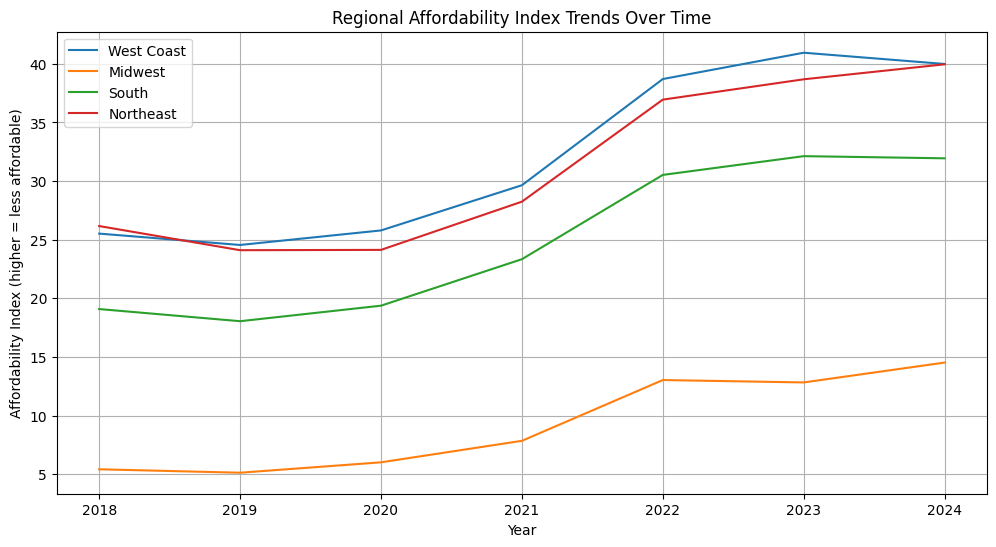

In [37]:
# Recalculate Affordability Index for all years
df = us_report.copy()
metrics = ["Mortgage_Burden_pct", "Rent_Burden_pct", "Price_To_Income", "Months_Supply"]
for m in metrics:
    df[m + "_norm"] = (df[m] - df[m].min()) / (df[m].max() - df[m].min()) * 100

weights = {
    "Mortgage_Burden_pct_norm": 0.30,
    "Rent_Burden_pct_norm": 0.25,
    "Price_To_Income_norm": 0.25,
    "Months_Supply_norm": 0.20
}

df["Affordability_Index"] = (
    df["Mortgage_Burden_pct_norm"] * weights["Mortgage_Burden_pct_norm"] +
    df["Rent_Burden_pct_norm"] * weights["Rent_Burden_pct_norm"] +
    df["Price_To_Income_norm"] * weights["Price_To_Income_norm"] +
    df["Months_Supply_norm"] * weights["Months_Supply_norm"]
)

# Define regions
regions = {
    "West Coast": ["California", "Oregon", "Washington"],
    "Midwest": ["Ohio", "Indiana", "Illinois", "Iowa", "Nebraska", "Kansas", "Missouri"],
    "South": ["Florida", "Texas", "Georgia", "Alabama", "Mississippi"],
    "Northeast": ["New York", "Massachusetts", "Rhode Island", "Vermont", "Delaware"]
}

# Compute regional averages
regional_trends = {}
for region, states in regions.items():
    regional_trends[region] = (
        df[df["State_Name"].isin(states)]
        .groupby("Year")["Affordability_Index"]
        .mean()
    )

# Plot
plt.figure(figsize=(12,6))
for region, trend in regional_trends.items():
    plt.plot(trend.index, trend.values, label=region)

plt.title("Regional Affordability Index Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Affordability Index (higher = less affordable)")
plt.legend()
plt.grid(True)
plt.show()

## 📊 Phase 6 - Overall findings (Temporal Dynamic Analysis)
- West Coast & Northeast → consistently the least affordable, both climbing toward index ~40 by 2024.
- South → affordability worsened sharply around 2021–22, then stabilized around ~32.
- Midwest → remains the most affordable, though creeping upward from ~5 to ~15.
  
This confirms a structural divide: coasts are entrenched in crisis, while the Midwest is still a safe haven but slowly eroding.


---

# Phase 7 — Forecasting

- Forecast regional trends using simple models (linear regression or ARIMA).
  
- West Coast & Northeast → likely to keep climbing.

- South → may plateau but remains vulnerable.

- Midwest → still affordable, but watch for upward drift


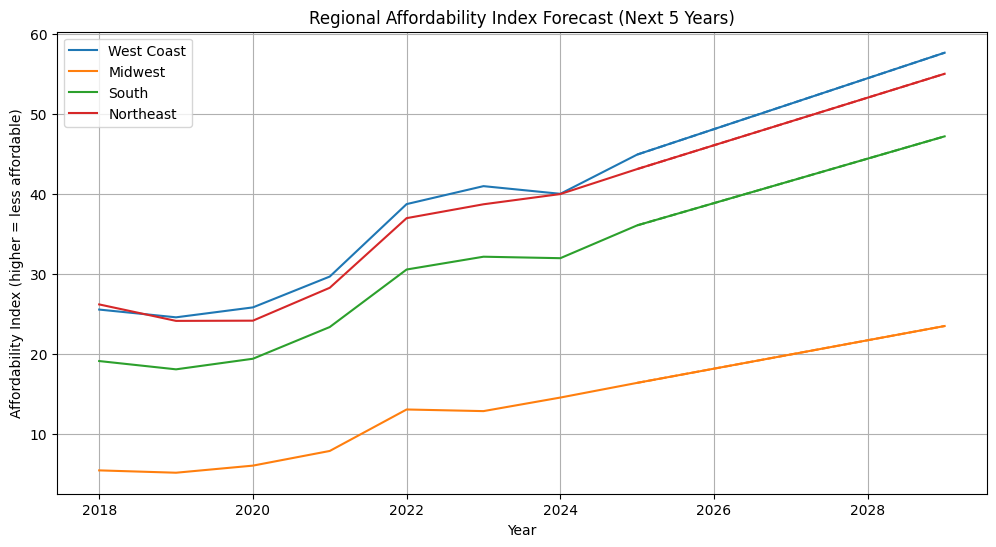

In [38]:
from sklearn.linear_model import LinearRegression

# Forecast horizon
forecast_years = 5

plt.figure(figsize=(12,6))

for region, trend in regional_trends.items():
    # Prepare data
    X = trend.index.values.reshape(-1,1)
    y = trend.values
    
    # Fit linear regression
    model = LinearRegression()
    model.fit(X, y)
    
    # Forecast next 5 years
    future_X = np.arange(X.max()+1, X.max()+forecast_years+1).reshape(-1,1)
    future_y = model.predict(future_X)
    
    # ✅ Combine historical + forecast for a continuous line
    all_years = np.concatenate([X.flatten(), future_X.flatten()])
    all_values = np.concatenate([y, future_y])
    
    # Plot continuous line
    plt.plot(all_years, all_values, label=f"{region}")
    
    # Add dashed segment for forecast portion
    plt.plot(future_X.flatten(), future_y, linestyle="--", color=plt.gca().lines[-1].get_color())

plt.title("Regional Affordability Index Forecast (Next 5 Years)")
plt.xlabel("Year")
plt.ylabel("Affordability Index (higher = less affordable)")
plt.legend()
plt.grid(True)
plt.show()

## 📊 Phase 7 - findings (Temporal Dynamic Analysis)
The forecast shows that housing affordability is projected to keep worsening across all regions, with the West Coast and Northeast remaining the least affordable, the South holding a middle position, and the Midwest staying most affordable but gradually eroding, which underscores a persistent and widening regional divide in affordability.

---

# Summary
Housing affordability in the United States reveals a stark and persistent divide: coastal and mountain states are locked in structural crisis, the South is elevated but stabilizing, and the Midwest remains the most affordable yet is slowly eroding. Heatmaps show the worst affordability concentrated in Hawaii, California, Rhode Island, and other coastal regions, while the Midwest and Great Plains stand out as safe havens. Rankings confirm this divide, with affordability consistently lowest in the interior states and highest along the coasts. Temporal analysis adds another layer: affordability stress has risen across all regions since 2018, with sharp jumps around 2021–22, and forecasts suggest that without intervention, the gap will widen further. The storyline is clear — affordability challenges are not temporary shocks but structural realities, and the Midwest’s relative advantage may not last forever.

# Recommendation
- **Policy Makers:** expand housing supply in coastal states, strengthen renter protections in the South, and preserve affordability in the Midwest before erosion accelerates.
  
- **Market Opportunities:** investors and developers should anticipate stronger demand in affordable Midwest markets, while coastal markets may require innovative affordability solutions.

- **Migration Insights:** households seeking affordability may continue shifting inland, reinforcing the Midwest’s role as a safe haven.


In [39]:
us_report

,State_Name,State_Abbr,Year,Median_Home_Value,Median_Income,Price_To_Income,Mortgage_Rate_pct,Median_Rent_Price,Months_Supply,Average_CPI,...,Mortgage_Burden_pct,Rent_Burden_pct,Annual_Housing_Cost,Affordability_pct,Affordability_Gap_pct,Mortgage_Burden_pct_norm,Rent_Burden_pct_norm,Price_To_Income_norm,Months_Supply_norm,Affordability_Index
0,Alabama,AL,2018,129762.299565,61420.0,2.112704,4.539042,936.883392,679.0,251.099500,...,10.323675,18.304462,9195.571721,14.971624,NaN,9.859243,37.426299,11.369698,8.329900,16.822752
1,Alabama,AL,2019,134567.353669,68110.0,1.975736,3.933750,976.474873,599.5,255.652583,...,8.982873,17.204079,9078.716460,13.329491,-7.189251,7.305475,32.277700,9.676855,7.238017,14.127885
2,Alabama,AL,2020,143369.238170,65600.0,2.185507,3.113667,1039.972753,481.0,258.855750,...,8.974755,19.023892,9041.562236,13.782869,10.226092,7.290012,40.792449,12.269487,5.610493,16.574587
3,Alabama,AL,2021,158678.920460,65360.0,2.427768,2.955708,1107.497850,314.0,270.967917,...,9.770559,20.333498,9876.973776,15.111649,11.044352,8.805747,46.919986,15.263679,3.316852,18.851011
4,Alabama,AL,2022,178933.335789,63870.0,2.801524,5.327500,1201.640283,309.0,292.625417,...,14.980675,22.576614,13504.690792,21.144028,15.044084,18.729230,57.415338,19.883056,3.248180,25.593004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,Wyoming,WY,2020,248784.464638,78500.0,3.169229,3.113667,951.258314,268.0,258.855750,...,13.014397,14.541528,15689.559693,19.986700,6.188231,14.984144,19.819848,24.427647,2.685071,16.094131
346,Wyoming,WY,2021,269750.522038,81580.0,3.306577,2.955708,972.385924,204.0,270.967917,...,13.307327,14.303299,16790.628677,20.581795,4.503831,15.542075,18.705191,26.125175,1.806071,16.231428
347,Wyoming,WY,2022,286808.298053,77920.0,3.680805,5.327500,1065.982646,186.0,292.625417,...,19.682480,16.416571,21646.371061,27.780250,10.809931,27.684554,28.593012,30.750387,1.558852,23.452987
348,Wyoming,WY,2023,299161.551197,79200.0,3.777292,6.795375,1132.122292,183.5,304.704167,...,23.628945,17.153368,25295.678404,31.938988,2.664436,35.201215,32.040426,31.942911,1.524516,26.861102
